Importing Libraries 

In [28]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
sns.set 


<function seaborn.rcmod.set(*args, **kwargs)>

In [29]:
df = pd.read_csv('C:\\Users\\Karam\\OneDrive\\Desktop\\practice\\california_housing.csv')

In [30]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [31]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [33]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


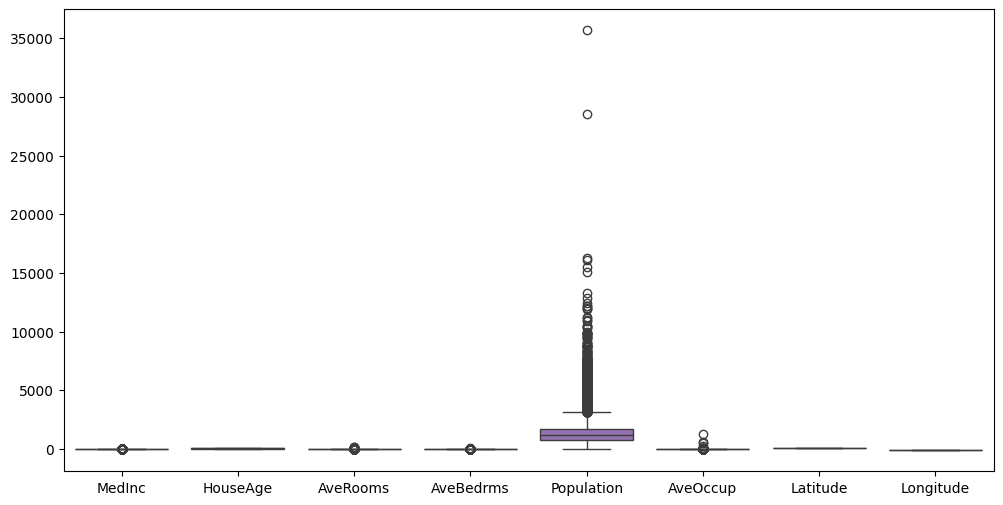

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

In [35]:
df.drop(['AveBedrms'], axis=1, inplace=True) # this reduces the multicolinearity in the dataset

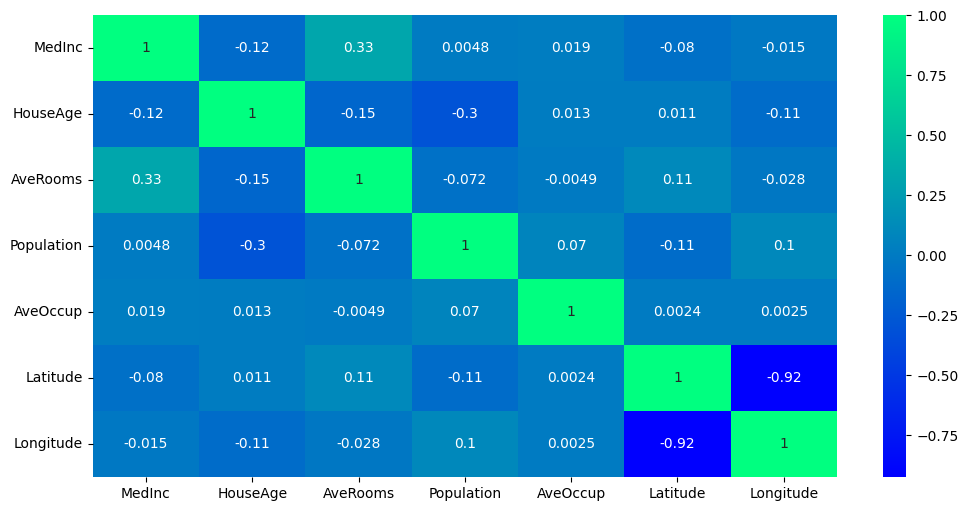

In [36]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(),annot = True, cmap='winter')
plt.show()

In [37]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [38]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [46]:
x=df.drop('MedInc', axis=1)

In [47]:
y=df['MedInc']

In [52]:
importance = model.feature_importances_
import pandas as pd
fea_imp = pd.Series(importance , index = x.columns).sort_values(ascending=False)

In [53]:
print(fea_imp)

AveRooms      0.593616
Latitude      0.171291
Longitude     0.141332
AveOccup      0.036917
Population    0.033226
HouseAge      0.023618
dtype: float64


In [54]:
x.drop(['Population','HouseAge'], axis=1, inplace=True)

In [55]:
x.columns

Index(['AveRooms', 'AveOccup', 'Latitude', 'Longitude'], dtype='object')

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [58]:
from sklearn.tree import DecisionTreeRegressor

In [59]:
for d in [3,5,7,10]:
    model = DecisionTreeRegressor(random_state = 42, max_depth = d)
    model.fit(x_train,y_train)
    print(f"Model with depth {d} has a training score of {model.score(x_train,y_train)} and a testing score of {model.score(x_test,y_test)}")

Model with depth 3 has a training score of 0.47725707913245163 and a testing score of 0.47367427126365014
Model with depth 5 has a training score of 0.5692497761481152 and a testing score of 0.5548664434434507
Model with depth 7 has a training score of 0.6685478795242616 and a testing score of 0.6222824565730349
Model with depth 10 has a training score of 0.7764989076887188 and a testing score of 0.6476647439455891


so choosing 7th depth 

In [ ]:
model_update = DecisionTreeRegressor(random_state = 42, max_depth = 7)
model_update.fit(x_train,y_train) 


,criterion,'squared_error'
,splitter,'best'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


So, choosing depth 7 of decision tree

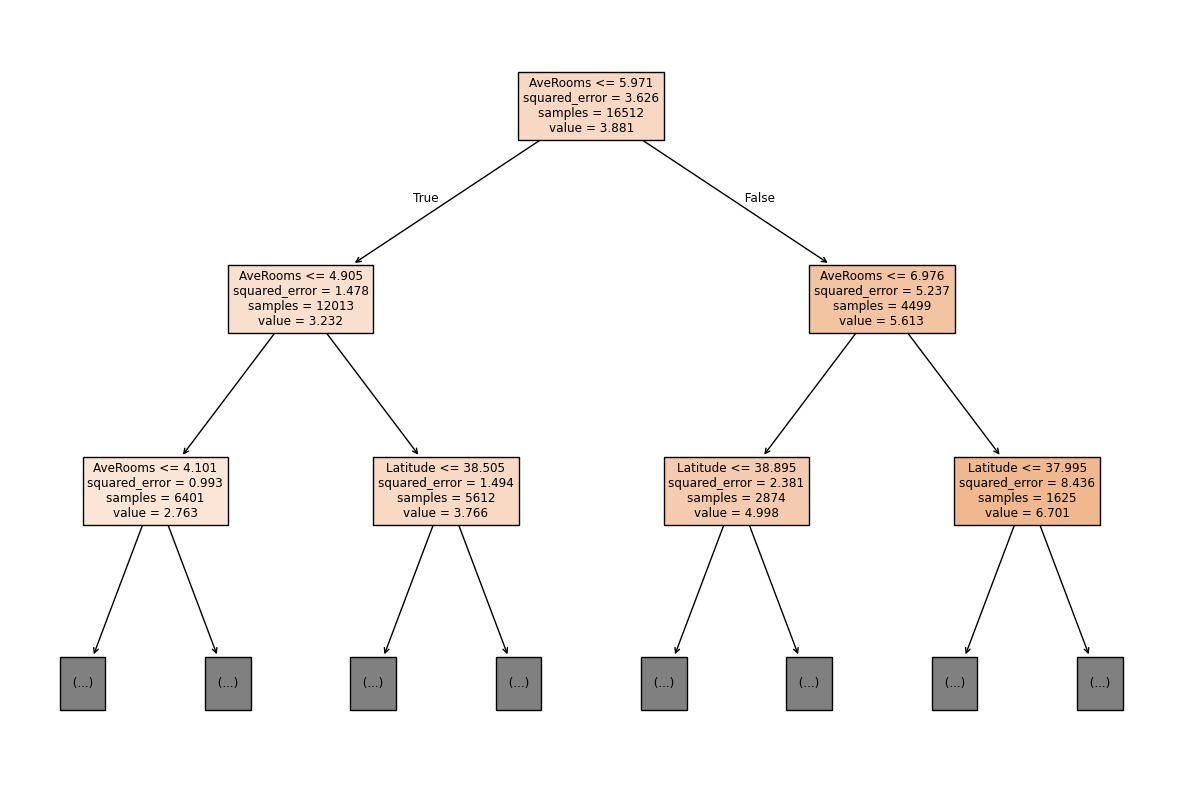

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10),facecolor='white')
plot_tree(model_update,max_depth = 2 ,feature_names=x.columns,filled = True )
plt.show()

In [81]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score , mean_absolute_error

In [86]:
r2 = r2_score(y_test,y_pred)

In [87]:
print(r2)

0.6476647439455891


In [88]:
print(mean_absolute_error(y_test,y_pred))

0.7540084052520257


In [90]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

1.116691440783267


Error Analysis

In [91]:
import pandas as pd
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results["Error"] = abs(results['Actual'] - results['Predicted'])
print(results.sort_values('Error', ascending=False).head(10))

        Actual  Predicted      Error
9811   14.4113   2.773450  11.637850
9634    3.2262  11.585977   8.359777
19422   3.3036  11.585977   8.282377
9192    4.5491  12.632000   8.082900
17972   3.1103  10.823800   7.713500
19516   1.3036   9.001950   7.698350
19434   3.9844  11.585977   7.601577
3014    4.5724  11.779400   7.207000
6688    0.4999   7.198142   6.698242
18505   9.5908   3.119061   6.471739


In [95]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, max_depth=10)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [98]:
from sklearn.metrics import r2_score , mean_absolute_error,root_mean_squared_error
r2 = r2_score(y_test,y_pred)
print(r2)
print(mean_absolute_error(y_test,y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

0.7239967093544695
0.681778727127477
0.9883534124253758


In [99]:
from xgboost import XGBRegressor 

In [100]:
model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [101]:
from sklearn.metrics import r2_score , mean_absolute_error , root_mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.749219853684209
0.6491937969365323
0.9421102129669121


In [104]:
from lightgbm import LGBMRegressor
model = LGBMRegressor(n_estimators = 200 ,learning_rate = 0.1)
model.fit(x_train,y_train)
y_pred  = model.predict(x_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000632 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 4
[LightGBM] [Info] Start training from score 3.880754


In [105]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(root_mean_squared_error(y_test,y_pred))

0.7626020965586973
0.6321367795409372
0.9166289630556527
